## 1. 파이프라인 활용

- make_column_selector                            : dtype/이름 기반 자동 컬럼 선택
- make_pipeline / make_column_transformer          : 이름을 자동 생성해주는 축약 API
- OneHotEncoder(drop="if_binary", min_frequency=..., handle_unknown="infrequent_if_exist")
   -> 이진 컬럼 자동 축소 + 희소 카테고리 자동 그룹핑 (커스텀 코드 불필요)
- SimpleImputer(add_indicator=True)                : 결측치 대체 + 결측 여부 플래그 자동 생성
- PowerTransformer(method="yeo-johnson")            : 왜도 완화 + 표준화를 한 번에 (log 변환 수동 불필요)
- ColumnTransformer(remainder=...)                  : 미지정 컬럼 처리 정책
- FeatureUnion                                      : 서로 다른 전처리 결과를 병렬로 합치기
- Pipeline(memory=...)                              : 중간 결과 캐싱 (재실행 시 재계산 방지)
- Pipeline 슬라이싱 ([:n])                          : 중간 단계 결과 확인 (디버깅)

In [1]:
import numpy as np
import pandas as pd

from sklearn import set_config
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42

# 전역 설정: 모든 transformer의 출력을 pandas DataFrame으로, Jupyter는 파이프라인을 다이어그램(HTML)으로 보여줌
set_config(transform_output="pandas", display="diagram")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

In [3]:
# 1. 데이터 로드 & Train/Test 분할 (fit 이전에 반드시 분할)
df = pd.read_csv("creditApprovalUCI.csv")
X_raw = df.drop(columns=["A16"])
y = df["A16"]

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"STEP 1. train {X_train.shape}, test {X_test.shape}")


STEP 1. train (552, 15), test (138, 15)


In [4]:
# 2. make_column_selector로 컬럼을 "자동" 선택
numeric_selector = make_column_selector(dtype_include="number")
categorical_selector = make_column_selector(dtype_include=object)

print("\nSTEP 2. make_column_selector 자동 선택 결과")
print(" 수치형 :", numeric_selector(X_train))
print(" 범주형 :", categorical_selector(X_train))


STEP 2. make_column_selector 자동 선택 결과
 수치형 : ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
 범주형 : ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


- QuantileTransformer: 데이터를 강제로 정규분포(또는 균등분포) 형태로 매핑, 이상치 강전, skewed데이터에 적용
- TargetEncoder: 범주를 타깃(y) 평균값으로 인코딩, 고카디널리티 범주형(A6=14개, A7=9개)에 OneHot보다 컬럼 수가 안 늘어나 효율적
- KBinsDiscretizer: 연속형 변수를 구간(bin)으로 잘라 범주형처럼 변환, "연령대", "소득구간" 같은 해석 가능한 피처 생성에 유용
- FunctionTransformer : 파이썬 함수를 sklearn transformer(= fit/transform 인터페이스를 가진 객체)로 바꿔주는 래퍼, 학습(fit)하지 않고 입력 → 출력 변환 수행 (예: log1p, 컬럼 선택, 파생변수 계산) 
    - func: 적용할 함수 (양방향 변환이 필요하면 inverse_func도 지정 가능)
    - feature_names_out: 출력 컬럼명을 어떻게 정할지 ("one-to-one"이면 입력=출력 컬럼명 동일, 커스텀 함수면 직접 지정)
    - validate: 입력을 numpy array로 강제 변환할지 여부 (DataFrame 컬럼명 유지하려면 False 또는 미지정)
    - kw_args: 함수에 추가 인자를 넘길 때 사용
- PowerTransformer: 왜도(skewness)가 큰 수치형 변수를 정규분포에 가깝게 변환 + 표준화(평균 0, 분산 1)
    - method="yeo-johnson"(기본값, 음수/0 포함 가능) 또는 "box-cox"(양수만 가능) 중 선택
    - 기존 log1p 변환과의 차이: log1p는 고정된 변환식이라 데이터에 따라 최적이 아닐 수 있는데, PowerTransformer는 데이터에 맞춰 학습(fit), 유연함

- A3, A8, A11, A15처럼 왜도가 심한(최대 13.14) 컬럼을 수동 로그변환+별도 스케일러 없이, 파이프라인 한 스텝으로 정규화 + 표준화 적용

In [5]:
# 3. 서브 파이프라인 -  make_pipeline: step 이름을 자동으로 붙여주는 축약 함수

# 3-1) 수치형: 결측 대체 + 결측 여부 플래그 자동 생성 -> Yeo-Johnson 파워변환(왜도 완화+표준화 동시)
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median", add_indicator=True),  # add_indicator=True -> "A3_missing" 같은 컬럼 자동 추가
    PowerTransformer(method="yeo-johnson"),                 # 로그변환 수동 구현 없이 왜도 완화 + 표준화
)

# 3-2) 범주형: 결측 대체 -> OneHotEncoder 하나로 이진(drop="if_binary") + 희소범주 자동 그룹핑(min_frequency)까지 전부 처리

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(
        drop="if_binary",                       # 이진 카테고리는 컬럼 1개로 (0/1)
        min_frequency=0.03,                      # 전체의 3% 미만 등장하는 범주는 자동으로 "infrequent" 그룹핑
        handle_unknown="infrequent_if_exist",    # 학습 시 못 본 범주 -> infrequent 그룹으로 흡수 (에러 방지)
        sparse_output=False,
    ),
)

print("\nSTEP 3. 서브 파이프라인 구성 (make_pipeline, 커스텀 클래스 0개)")
print(numeric_pipeline)
print(categorical_pipeline)


STEP 3. 서브 파이프라인 구성 (make_pipeline, 커스텀 클래스 0개)
Pipeline(steps=[('simpleimputer',
                 SimpleImputer(add_indicator=True, strategy='median')),
                ('powertransformer', PowerTransformer())])
Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder',
                 OneHotEncoder(drop='if_binary',
                               handle_unknown='infrequent_if_exist',
                               min_frequency=0.03, sparse_output=False))])


In [6]:
# 4. make_column_transformer로 컬럼 그룹별 전처리 통합
preprocessor = make_column_transformer(
    (numeric_pipeline, numeric_selector),
    (categorical_pipeline, categorical_selector),
    remainder="drop",
    verbose_feature_names_out=True,
)

print("\nSTEP 4. make_column_transformer 완성")
print(preprocessor)


STEP 4. make_column_transformer 완성
ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('powertransformer',
                                                  PowerTransformer())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x0000025285399160>),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='if_binary',
                                                            

In [ ]:
# 5. FeatureUnion은 여러 transformer를 같은 입력 X에 적용해서 결과를 concat: Columnstransformer는 컬럼을 나누어 서로 다른 pipe로 보내지만, feature union은 전체 입력을 여러 pipe로 보냄. 이후 처리는 동일
#   FeatureUnion으로 "파생 변수 파이프라인"을 병렬로 결합-> ColumnTransformer 결과 + 직접 계산한 파생 피처를 옆으로 이어붙임

def add_income_credit_ratio(X: pd.DataFrame) -> pd.DataFrame:
    ratio = X["A8"] / X["A2"].replace(0, np.nan)
    return ratio.to_frame("A8_to_A2_ratio").fillna(0.0)

def ratio_feature_names_out(transformer, input_features): #functiontransformer의 출력 컬럼명을 지정하는 콜백 함수
    return np.array(["A8_to_A2_ratio"])

ratio_feature = FunctionTransformer(
    add_income_credit_ratio,
    feature_names_out=ratio_feature_names_out,
)#transformer 객체 지정

feature_union = FeatureUnion(transformer_list=[
    ("column_preprocessing", preprocessor),  # 그룹별 전처리 결과 (수치+범주 인코딩)
    ("engineered_ratio", ratio_feature),     # 원본 컬럼으로 직접 계산한 파생 피처
])

print("\nSTEP 5. FeatureUnion으로 전처리 결과 + 파생 피처 결합")



STEP 5. FeatureUnion으로 전처리 결과 + 파생 피처 결합


In [16]:
# 6. 전체를 하나의 Pipeline으로 감싸고, memory 캐싱 적용 : 같은 파이프라인을 반복 실행/튜닝할 때 이미 계산된 단계는 재사용
full_pipeline = Pipeline(
    steps=[("features", feature_union)],
    memory="sklearn_cache",  # 캐시 디렉토리. 동일 입력이면 재계산하지 않음
)

X_train_processed = full_pipeline.fit_transform(X_train, y_train)
X_test_processed = full_pipeline.transform(X_test)

print("\n" + "=" * 70)
print("STEP 6. 전체 파이프라인 적용 결과")
print("전처리 전:", X_train.shape, "-> 전처리 후:", X_train_processed.shape)
print("\n컬럼 목록 (앞부분):")
print(list(X_train_processed.columns)[:10], "...")
print("\n마지막 3개 컬럼 (add_indicator + 파생피처 확인):")
print(list(X_train_processed.columns)[-3:])
print("\n미리보기:")
print(X_train_processed.head())



STEP 6. 전체 파이프라인 적용 결과
전처리 전: (552, 15) -> 전처리 후: (552, 42)

컬럼 목록 (앞부분):
['column_preprocessing__pipeline-1__A2', 'column_preprocessing__pipeline-1__A3', 'column_preprocessing__pipeline-1__A8', 'column_preprocessing__pipeline-1__A11', 'column_preprocessing__pipeline-1__A14', 'column_preprocessing__pipeline-1__A15', 'column_preprocessing__pipeline-1__missingindicator_A2', 'column_preprocessing__pipeline-1__missingindicator_A3', 'column_preprocessing__pipeline-1__missingindicator_A8', 'column_preprocessing__pipeline-1__missingindicator_A14'] ...

마지막 3개 컬럼 (add_indicator + 파생피처 확인):
['column_preprocessing__pipeline-2__A13_s', 'column_preprocessing__pipeline-2__A13_infrequent_sklearn', 'engineered_ratio__A8_to_A2_ratio']

미리보기:
     column_preprocessing__pipeline-1__A2  column_preprocessing__pipeline-1__A3  column_preprocessing__pipeline-1__A8  \
177                             -0.297205                              1.172300                              0.338679   
401                  

In [17]:
# 7. Pipeline 슬라이싱으로 중간 단계 결과
print("STEP 7. Pipeline 슬라이싱으로 중간 산출물만 확인")
intermediate = full_pipeline.named_steps["features"].transformer_list[0][1]  # column_preprocessing만 추출
print("ColumnTransformer 단계만 다시 적용한 결과 shape:",
      intermediate.transform(X_train).shape)

STEP 7. Pipeline 슬라이싱으로 중간 산출물만 확인
ColumnTransformer 단계만 다시 적용한 결과 shape: (552, 41)


In [18]:
# 8. 전처리 결과 저장
X_train_processed.assign(A16=y_train.values).to_csv("credit_train_processed_v2.csv", index=False)
X_test_processed.assign(A16=y_test.values).to_csv("credit_test_processed_v2.csv", index=False)
print("\nSTEP 9. 저장 완료 -> credit_train_processed_v2.csv / credit_test_processed_v2.csv")




STEP 9. 저장 완료 -> credit_train_processed_v2.csv / credit_test_processed_v2.csv


In [19]:
full_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('features', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",'sklearn_cache'
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('column_preprocessing', ...), ('engineered_ratio', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent 

In [62]:
import joblib
joblib.dump(preprocessor, "pipe.pkl")  #pickle는 데이터가 크면 느릴 수 있음
joblib.dump(preprocessor, "pipe.joblib") #권장, 내부적으로 numpy array를 최적화해서 저장하여 빠르고 용량도 효율적
test_pkl = joblib.load("pipe.pkl")
test_joblib = joblib.load("pipe.joblib")

#### crx.data에 적용

- selectKBest: y에 중요한 변수 선택

In [15]:
import pandas as pd, numpy as np
from sklearn.feature_selection import SelectKBest, f_classif
df = pd.read_csv("creditset2.csv")
df.groupby("default10yr").mean()

,income,age,loan
default10yr,,,
0,45318.317216,43.321309,3978.171771
1,45412.188607,26.401412,7272.856747


In [ ]:
X = df.drop(columns = "default10yr")
y = df.default10yr
Xnum = X.select_dtypes(include="number")  # 결측 먼저 처리 필수
sel = SelectKBest(f_classif, k=1)
sel.fit_transform(Xnum, y)      # ndarray (또는 pandas 출력 설정 시 DataFrame)

#### Pipeline 연습

In [18]:
import numpy as np, pandas as pd
from sklearn.compose import ColumnTransformer, make_column_selector as mcs
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score

# 1) 로드
df = pd.read_csv("crx.data", header=None, na_values="?", names=[f"A{i}" for i in range(1, 17)])
X, y = df.drop(columns="A16"), LabelEncoder().fit_transform(df["A16"])  # + → 1, - → 0

In [19]:
# 2) 수치: 결측 , log1p, 표준화 , (PCA,kBest) 병렬 결합
num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median", add_indicator=True)),
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("sc",  StandardScaler()),
    ("fu",  FeatureUnion([("pca", PCA(n_components=3)),
                          ("kbest", SelectKBest(f_classif, k=3))])),
])

num_pipe.fit_transform( X.select_dtypes(include= "number"), y)

,pca__pca0,pca__pca1,pca__pca2,kbest__A8,kbest__A11,kbest__A15
0,-1.132815,-0.128294,-0.248311,-0.033286,0.007187,-0.932897
1,2.307160,0.096762,0.294204,0.743023,1.357832,1.053758
2,-0.814986,1.011145,0.374687,0.106455,-0.740117,1.174803
3,0.505376,0.167199,0.005153,0.957752,1.191637,-0.497793
4,-0.809861,-0.383891,-0.613506,0.213432,-0.740117,-0.932897
...,...,...,...,...,...,...
685,-0.756979,-0.388678,-0.628209,-0.033286,-0.740117,-0.932897
686,-0.160085,1.273902,0.514634,0.348270,0.444333,0.943645
687,0.213229,-0.374471,-0.480519,0.348270,0.007187,-0.715345
688,-1.789108,1.712377,0.461667,-1.056811,-0.740117,1.145307


- 파이프 적용 순서  
model.fit(Xtr, ytr)
---Pipeline.fit(X, y)  
------pre.fit_transform(X, y)                    y 그대로 넘김  
---------ColumnTransformer: 컬럼만 분할, y는 복제  
------------num_pipe.fit_transform(X[수치컬럼], y)  
---------------SimpleImputer.fit(X, y)           y 받지만 무시  
---------------FunctionTransformer.fit(X, y)     무시  
---------------StandardScaler.fit(X, y)          무시  
---------------FeatureUnion.fit_transform(X, y)  y 그대로 넘김  
------------------PCA.fit_transform(X, y)        무시 (비지도)  
------------------SelectKBest.fit_transform(X, y) y 실제로 사용  

In [ ]:
#참고: 특정 컬럼을 지정한 변환
ColumnTransformer([
    ("log", FunctionTransformer(np.log1p), ["A15"]),
    ("raw", "passthrough", ["A2", "A3"]),      # A2, A3는 원본 그대로 출력에 포함
], remainder="passthrough").fit_transform(X)

,log__A15,raw__A2,raw__A3,remainder__A1,remainder__A4,remainder__A5,remainder__A6,remainder__A7,remainder__A8,remainder__A9,remainder__A10,remainder__A11,remainder__A12,remainder__A13,remainder__A14
0,0.000000,30.83,0.000,b,u,g,w,v,1.25,t,t,1,f,g,202.0
1,6.329721,58.67,4.460,a,u,g,q,h,3.04,t,t,6,f,g,43.0
2,6.715383,24.50,0.500,a,u,g,q,h,1.50,t,f,0,f,g,280.0
3,1.386294,27.83,1.540,b,u,g,w,v,3.75,t,t,5,t,g,100.0
4,0.000000,20.17,5.625,b,u,g,w,v,1.71,t,f,0,f,s,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0.000000,21.08,10.085,b,y,p,e,h,1.25,f,f,0,f,g,260.0
686,5.978886,22.67,0.750,a,u,g,c,v,2.00,f,t,2,t,g,200.0
687,0.693147,25.25,13.500,a,y,p,ff,ff,2.00,f,t,1,t,g,200.0
688,6.621406,17.92,0.205,b,u,g,aa,v,0.04,f,f,0,f,g,280.0


In [29]:
# 3) 범주: 최빈값 대치 → OHE (희소 범주는 묶음)
cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist",
                          min_frequency=0.02, sparse_output=False)), #drop="first" : 첫 범주 제거, drop="if_binary": 이진범주만 1열, handle_unknow="infrequnt_if_exist": 소수 범주를 하나로.
])

cat_pipe.fit_transform(X.select_dtypes(exclude="number"))


,A1_a,A1_b,A4_u,A4_y,A4_infrequent_sklearn,A5_g,A5_p,A5_infrequent_sklearn,A6_aa,A6_c,...,A7_infrequent_sklearn,A9_f,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_s,A13_infrequent_sklearn
0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
686,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
687,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
688,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [33]:
# 4) 컬럼별 적용
pre = ColumnTransformer([
    ("num", num_pipe, mcs(dtype_include=np.number)),
    ("cat", cat_pipe, mcs(dtype_include=object)),
])

In [32]:
# 5) 학습·평가
Xtr, Xte, ytr, yte = train_test_split(X, y, stratify=y, test_size=.25, random_state=0)
model = Pipeline([("pre", pre), ("clf", LogisticRegression(max_iter=1000))])
model.fit(Xtr, ytr)
print("test acc:", model.score(Xte, yte))
print("cv  acc:", cross_val_score(model, X, y, cv=5).mean().round(3))
print(model[:-1].transform(Xtr).head(3))   # 중간 산출물 확인

test acc: 0.884393063583815
cv  acc: 0.832
     num__pca__pca0  num__pca__pca1  num__pca__pca2  num__kbest__A8  \
5         -0.465008       -0.919782       -0.034558        0.588530   
669       -0.151066       -1.177075        0.257966        0.135536   
355       -1.546657        0.973482       -0.676822       -0.164883   

     num__kbest__A11  num__kbest__A15  cat__A1_a  cat__A1_b  cat__A4_u  \
5          -0.736795        -0.906675        0.0        1.0        1.0   
669        -0.736795        -0.686490        0.0        1.0        0.0   
355         0.443423        -0.686490        1.0        0.0        1.0   

     cat__A4_y  ...  cat__A7_infrequent_sklearn  cat__A9_f  cat__A9_t  \
5          0.0  ...                         0.0        0.0        1.0   
669        1.0  ...                         0.0        1.0        0.0   
355        0.0  ...                         0.0        1.0        0.0   

     cat__A10_f  cat__A10_t  cat__A12_f  cat__A12_t  cat__A13_g  cat__A13_s  \
5  

In [35]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [34]:
import joblib
joblib.dump(model, "pipe_model.pkl")  #pickle는 데이터가 크면 느릴 수 있음
joblib.dump(model, "pipe_model.joblib") #권장, 내부적으로 numpy array를 최적화해서 저장하여 빠르고 용량도 효율적
test_model_pkl = joblib.load("pipe_model.pkl")
test_model_joblib = joblib.load("pipe_model.joblib")

## 2. Prefect

- 워크플로우 관리 스케쥴링 도구 : airflow, ....
- 파이썬 3.13 또는 코랩 커널

In [ ]:
!pip install prefect -q

In [36]:
from prefect import flow, task

@task
def hello(name: str):
    print(f"Hello {name}")

@flow
def hello_flow():
    hello("Prefect")

hello_flow()

05:22:38.230 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8816
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

05:22:44.160 | INFO    | Flow run 'devout-lobster' - Beginning flow run 'devout-lobster' for flow 'hello-flow'

Hello Prefect


05:22:44.204 | INFO    | Task run 'hello-9a0' - Finished in state Completed()

05:22:44.230 | INFO    | Flow run 'devout-lobster' - Finished in state Completed()

- @task: 실행 단위, 재시도, 캐시, 로깅 가능
- @flow: 워크플로 전체, task들을 조합
- Flow run: flow가 한 번 실행된 기록

In [37]:
from prefect import flow, task
import pandas as pd

@task(retries=2, retry_delay_seconds=5)
def load_csv(path: str) -> pd.DataFrame:
    return pd.read_csv(path)

@task
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.dropna()
    return df

@task
def save_parquet(df: pd.DataFrame):
    #df.to_parquet("output.parquet", index=False)   
    df.to_json("output.json", index=False, orient="records")

@flow
def etl_flow():
    df = load_csv("data.csv")
    df_clean = preprocess(df)
    save_parquet(df_clean)

etl_flow()


05:22:44.292 | INFO    | Flow run 'dark-oyster' - Beginning flow run 'dark-oyster' for flow 'etl-flow'

05:22:44.315 | INFO    | Task run 'load_csv-53c' - Finished in state Completed()

05:22:44.326 | INFO    | Task run 'preprocess-4be' - Finished in state Completed()

05:22:44.342 | INFO    | Task run 'save_parquet-337' - Finished in state Completed()

05:22:44.364 | INFO    | Flow run 'dark-oyster' - Finished in state Completed()

- 다른 예제

In [48]:
from prefect import flow, task, get_run_logger

@task
def preprocess(df: pd.DataFrame, subset: list[str] | None = None) -> pd.DataFrame:      #입력: df나 subset, subset은 리스트, 생략 시 None
    log = get_run_logger()
    before = len(df)
    df = df.drop_duplicates().dropna(subset=subset)
    log.info(f"{before:,} ---> {len(df):,} rows ({before - len(df):,} dropped)")
    return df

@task
def validate(df: pd.DataFrame, required: tuple[str, ...] = (), min_rows: int = 1): #입력: df, required, str 타입이 0개 이상, ()가 기본값이면 그냥 비어있는 set로 하여 아래 검사 통과
    if missing := set(required) - set(df.columns):      #:=는 왈러스 연산자, 대입과 동시에 값 사용, missing에 차집합 사용하며 그 값을 조건으로 평가
        raise ValueError(f"필수 컬럼 누락: {missing}")
    if len(df) < min_rows:
        raise ValueError(f"행 수 부족: {len(df)} < {min_rows}")

@flow(log_prints=True)
def etl_flow(subset=None, required=(), min_rows=1):
    clean = preprocess(raw, subset=subset)
    validate(clean, required=required, min_rows=min_rows)
    return clean

raw = pd.DataFrame({
        "id":    [1, 2, 3, 3, 4, 5],
        "score": [10, None, 30, 30, 40, None],
        "grade": ["A", "B", "C", "C", None, "E"],
    })
    

print(etl_flow(subset=["score"], required=("id", "score"), min_rows=3))

05:34:33.011 | INFO    | Flow run 'nonchalant-dinosaur' - Beginning flow run 'nonchalant-dinosaur' for flow 'etl-flow'

05:34:33.017 | INFO    | Task run 'preprocess-656' - 6 ---> 3 rows (3 dropped)

05:34:33.020 | INFO    | Task run 'preprocess-656' - Finished in state Completed()

05:34:33.026 | INFO    | Task run 'validate-28a' - Finished in state Completed()

05:34:33.054 | INFO    | Flow run 'nonchalant-dinosaur' - Finished in state Completed()

   id  score grade
0   1   10.0     A
2   3   30.0     C
4   4   40.0  None


- 병렬실행

In [49]:
#병렬실행
from prefect import flow, task

@task
def square(x):
    return x * x

@flow
def parallel_flow():
    results = square.map([1, 2, 3, 4, 5])
    print(results)

parallel_flow()


05:35:48.268 | INFO    | Flow run 'fragrant-deer' - Beginning flow run 'fragrant-deer' for flow 'parallel-flow'

[<prefect.futures.PrefectConcurrentFuture object at 0x000002BEAB029FD0>, <prefect.futures.PrefectConcurrentFuture object at 0x000002BEAD57E710>, <prefect.futures.PrefectConcurrentFuture object at 0x000002BEAD57EC10>, <prefect.futures.PrefectConcurrentFuture object at 0x000002BEAAE02FD0>, <prefect.futures.PrefectConcurrentFuture object at 0x000002BEACA4C180>]


05:35:48.281 | INFO    | Task run 'square-ec4' - Finished in state Completed()

05:35:48.285 | INFO    | Task run 'square-b30' - Finished in state Completed()

05:35:48.287 | INFO    | Task run 'square-563' - Finished in state Completed()

05:35:48.293 | INFO    | Task run 'square-3ee' - Finished in state Completed()

05:35:48.296 | INFO    | Task run 'square-e8e' - Finished in state Completed()

05:35:48.323 | INFO    | Flow run 'fragrant-deer' - Finished in state Completed()

- 병렬처리2

In [56]:
raw2 = pd.DataFrame({
        "id":    [1, 2, 3, 4],
        "score": [10, 10, 30, 40],
        "grade": ["A", "B", "C", "C"],
    })
raw2.to_csv("a.csv", index=False)
raw2.to_csv("b.csv", index=False)
raw2.to_csv("c.csv", index=False)

In [ ]:
import pandas as pd
from prefect import flow, task, get_run_logger, unmapped
from prefect.task_runners import ThreadPoolTaskRunner

@task(retries=2, retry_delay_seconds=3)
def load_csv(path: str) -> pd.DataFrame:
    get_run_logger().info(f"loading {path}")
    return pd.read_csv(path)

@task
def preprocess(df: pd.DataFrame, subset: list[str] | None = None) -> pd.DataFrame:
    log = get_run_logger()
    before = len(df)
    df = df.drop_duplicates().dropna(subset=subset)
    log.info(f"{before:,} ---> {len(df):,} rows ({before - len(df):,} dropped)")
    return df

@task
def merge(dfs: list[pd.DataFrame]) -> pd.DataFrame:
    out = pd.concat(dfs, ignore_index=True)
    get_run_logger().info(f"merged ---> {len(out):,} rows")
    return out

@flow(task_runner=ThreadPoolTaskRunner(max_workers=4), log_prints=True)
def etl_flow(paths: list[str], subset: list[str] | None = None):
    dfs = load_csv.map(paths)                  # PrefectFutureList
    cleaned = preprocess.map(dfs, subset=unmapped(subset))  #unmapped는 스코어 컬럼이 3개 df에 공유됨을 의미
    return merge(cleaned)                      # 여기서 자동으로 resolve

print(etl_flow(["a.csv", "b.csv", "c.csv"], subset=["score"]))

05:45:18.008 | INFO    | Flow run 'just-jackdaw' - Beginning flow run 'just-jackdaw' for flow 'etl-flow'

05:45:18.015 | INFO    | Task run 'load_csv-226' - loading a.csv

05:45:18.021 | INFO    | Task run 'load_csv-0a1' - loading c.csv

05:45:18.023 | INFO    | Task run 'load_csv-cb4' - loading b.csv

05:45:18.037 | INFO    | Task run 'load_csv-226' - Finished in state Completed()

05:45:18.043 | INFO    | Task run 'load_csv-0a1' - Finished in state Completed()

05:45:18.046 | INFO    | Task run 'load_csv-cb4' - Finished in state Completed()

05:45:18.066 | INFO    | Task run 'preprocess-12f' - 4 ---> 4 rows (0 dropped)

05:45:18.071 | INFO    | Task run 'preprocess-12f' - Finished in state Completed()

05:45:18.103 | INFO    | Task run 'preprocess-b6c' - 4 ---> 4 rows (0 dropped)

05:45:18.106 | INFO    | Task run 'preprocess-a21' - 4 ---> 4 rows (0 dropped)

05:45:18.111 | INFO    | Task run 'preprocess-b6c' - Finished in state Completed()

05:45:18.114 | INFO    | Task run 'preprocess-a21' - Finished in state Completed()

05:45:18.122 | INFO    | Task run 'merge-98f' - merged ---> 12 rows

05:45:18.125 | INFO    | Task run 'merge-98f' - Finished in state Completed()

05:45:18.157 | INFO    | Flow run 'just-jackdaw' - Finished in state Completed()

    id  score grade
0    1     10     A
1    2     10     B
2    3     30     C
3    4     40     C
4    1     10     A
5    2     10     B
6    3     30     C
7    4     40     C
8    1     10     A
9    2     10     B
10   3     30     C
11   4     40     C


In [ ]:
#스케쥴링(참고)
from prefect import flow
from prefect.server.schemas.schedules import CronSchedule

@flow
def daily_flow():
    print("run")

daily_flow.serve(
    name="daily-job",
    schedule=CronSchedule(cron="0 9 * * *")
)   #프롬프트에서 실행


## 3. EDA

Text(0.5, 1.0, 'Boxplot')

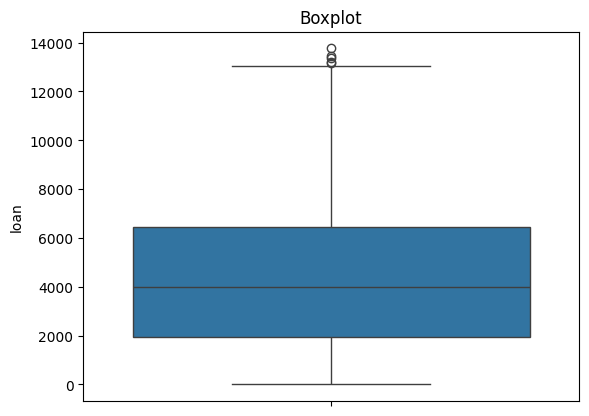

In [27]:
#seaborn 이용
import matplotlib.pyplot as plt
import seaborn as sns

credit = pd.read_csv("creditset2.csv")

sns.boxplot(y=credit['loan'])
plt.title('Boxplot')


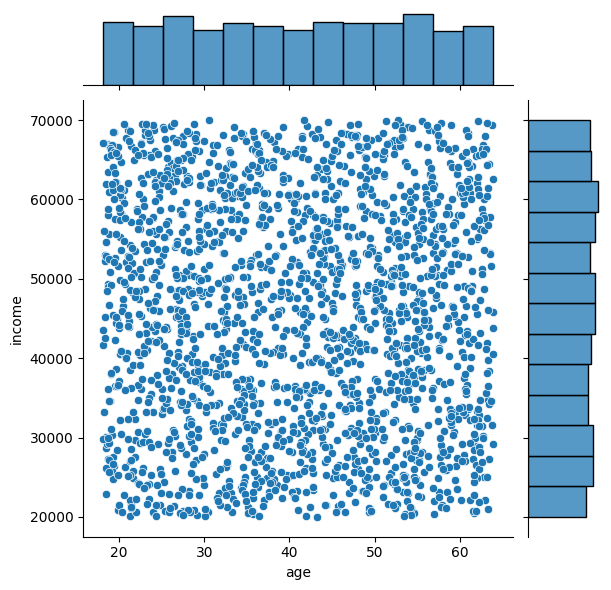

In [28]:
data = pd.read_csv("creditset2.csv")
join1 = sns.jointplot(x="age", y="income", data=data);
join1.savefig("join1.png")

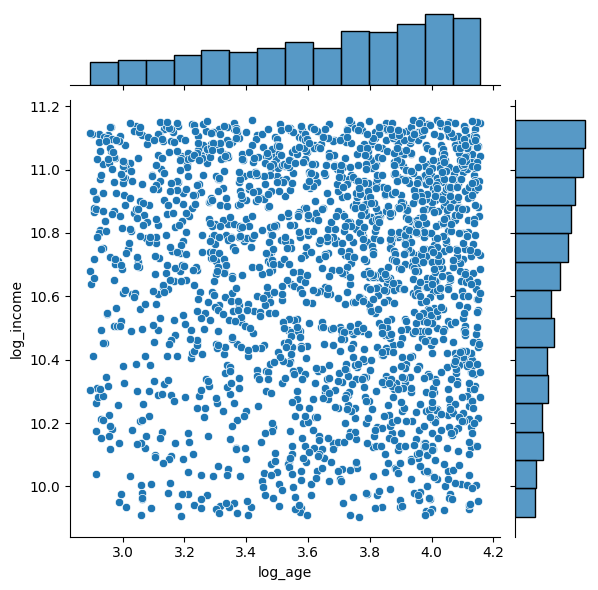

In [29]:
data["log_age"] = np.log( data.age )
data["log_income"] =np.log( data.income)

join1 = sns.jointplot(x="log_age", y="log_income", data=data);
join1.savefig("join1_log.jpg")

- tips데이터 연습

In [30]:
plt.clf()
tips = sns.load_dataset('tips')
sns.set_style("whitegrid")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


<Figure size 640x480 with 0 Axes>

<Axes: >

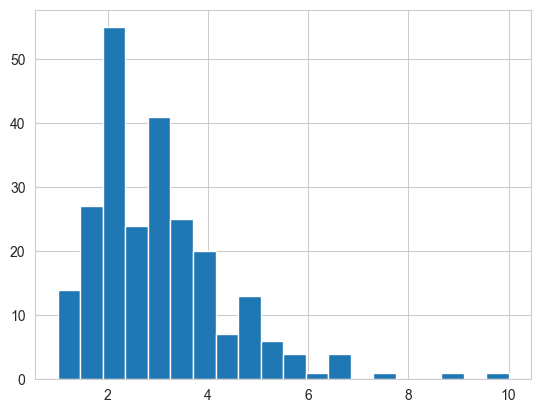

In [34]:
#tip에 대한 histogram
tips.tip.hist( bins = 20 )

- tips 데이터에서, time별로 total_bill의 박스플랏
- 각 boxplot은 성별로 나눠서 표현 (hue를 지정)

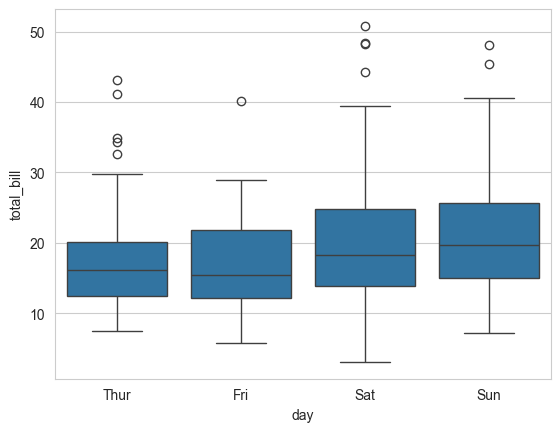

In [35]:
#box plot
sns.boxplot(x="day", y="total_bill", data=tips)
plt.show()

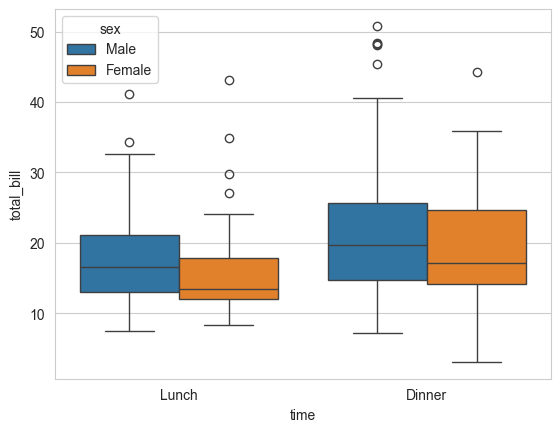

In [36]:
#box plot
sns.boxplot(x="time", y="total_bill", hue="sex", data=tips)
plt.show()

In [37]:
#pivot+Heatmap
#pivot
df1 = pd.DataFrame( {'x':['A','B', 'C', 'D', 'E', 'F'], 'y':[2021,2021,2021,2022,2022,2022], 'z':[1,2,3,4,5,6]})
df1
df1.pivot(index='x',columns='y', values='z').fillna(0) #index 중복 없어야 함.

y,2021,2022
x,,
A,1.0,0.0
B,2.0,0.0
C,3.0,0.0
D,0.0,4.0
E,0.0,5.0
F,0.0,6.0


In [38]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


<Axes: xlabel='year', ylabel='year'>

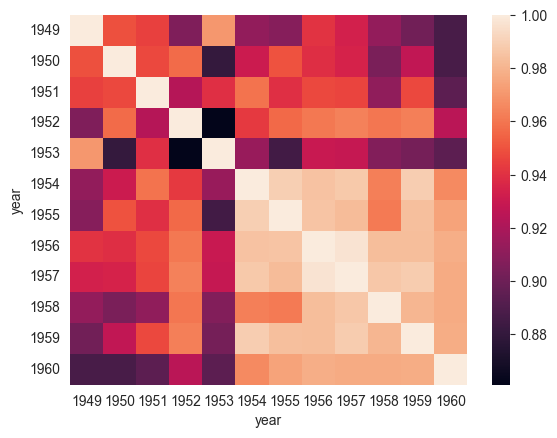

In [43]:
df = flights.pivot(index='month', columns='year', values='passengers') #행, 열 지정, 값 지정
df.head()
sns.heatmap( df.corr())

<Axes: xlabel='year', ylabel='year'>

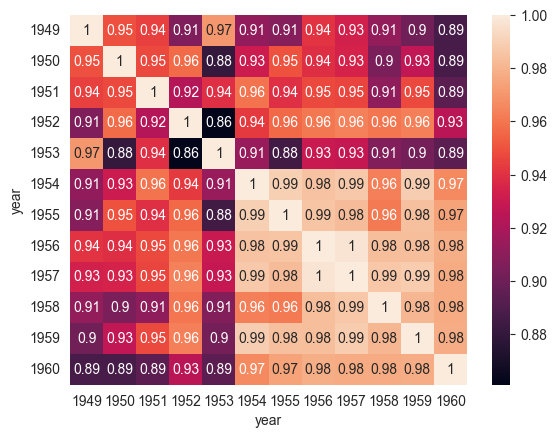

In [46]:
#heatmap+corr
sns.heatmap(df.corr(), annot=True)

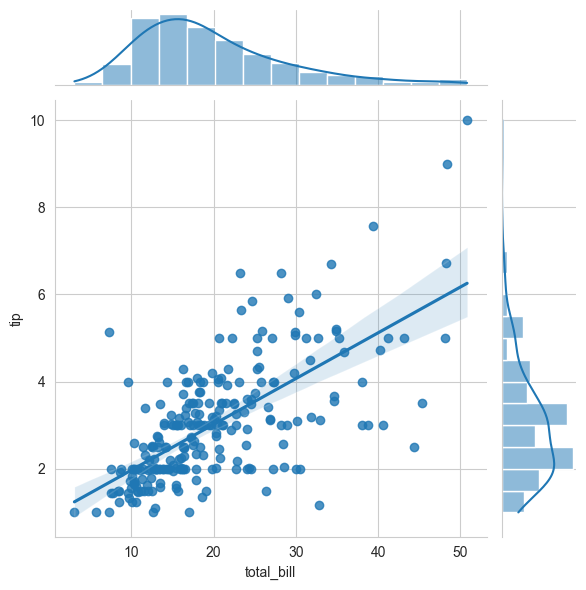

In [47]:
#jointplot
sns.jointplot(x="total_bill", y="tip", data=tips, kind="reg");
plt.savefig('join3.png')

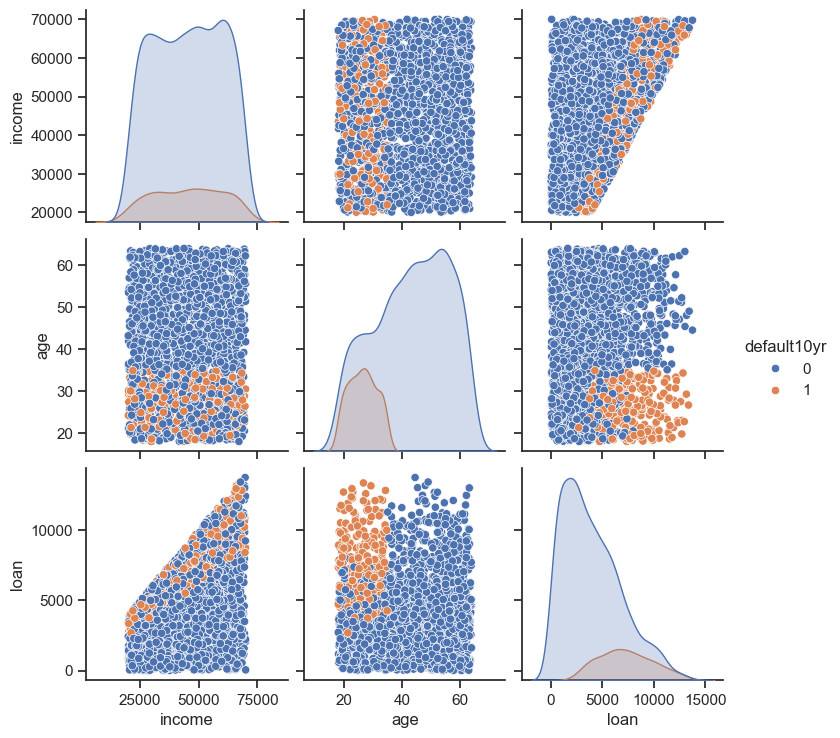

In [50]:
#pair plot
df = pd.read_csv("creditset2.csv")
sns.set_theme(style="ticks")
sns.pairplot(df, hue="default10yr")
plt.show()

- 선형관계의 시각화

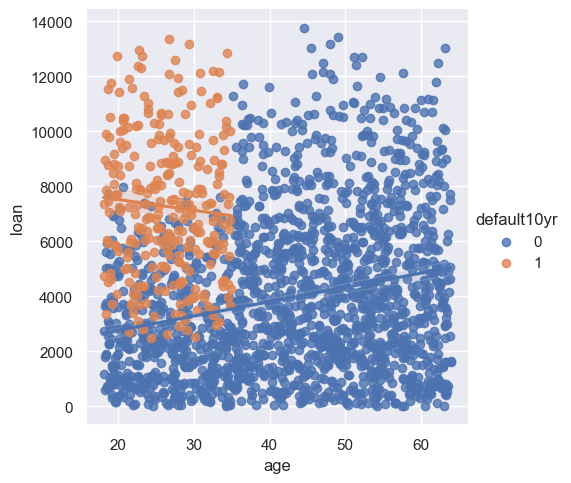

<Figure size 640x480 with 0 Axes>

In [53]:
#lm plot
sns.set_style("darkgrid")
sns.lmplot( x="age", y="loan", data=df, hue="default10yr")
plt.show()
plt.savefig("tip_lm.png")


## 4. streamlit에서 파일 업로드 후 파이프 적용 후 탐색

In [ ]:
#.py 파일
import streamlit as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

st.set_page_config(page_title="Multi Page", layout="wide")

def page_home():
    st.title("Home")
    st.subheader("현황")    

#upload
def data_upload():   
    uploaded_file = st.file_uploader(label="Select a file", type=["csv"])
    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)
        st.write(df.head(10))
        st.session_state["df"] = df #다른 함수에서도 접근 가능하도록 세션 지정
        st.success("데이터 저장 완료")

#explore
def data_eda():  
    tmp_df = st.session_state["df"]
    g = sns.pairplot(data=tmp_df )
    st.pyplot(g.figure)  

def data_eda2():  
    tmp_df = st.session_state["df"]
    fig, ax = plt.subplots()
    sns.heatmap(data=tmp_df.corr() )
    st.pyplot(fig)  

pages = {
    "Home": page_home,
    "Data upload": data_upload,
    "EDA1": data_eda,
    "EDA2": data_eda2,    
}

st.sidebar.subheader("처리 선택")
choice = st.sidebar.selectbox("이동", list(pages.keys()))
pages[choice]()


## 5. API 만들기
- 금일 사용할 API 생성
- API URL을 호출하면 JSON으로 정해진 개수의 행들을 return

In [ ]:
#.py 파일 
from fastapi import FastAPI
import pandas as pd
import numpy as np

app = FastAPI()

df = pd.read_csv("data.csv")

@app.get("/data")
def date_gen():
    #sample을 이용해서 내용을 넣어보세요.

    
    
    return  x.to_dict(orient="records")


## 6. 데이터베이스
1. DuckDB (덕DB): 분석(OLAP) 전용 임베디드 DB임, 컬럼 지향 구조라 대용량 집계·통계 처리 빠름, Parquet·CSV 파일을 로딩 없이 SQL로 바로 조회 가능함
    - 단점: 다중 사용자 동시 접속 부적합함, 트랜잭션·권한 관리 기능 약함, 서비스용 운영 DB로 쓰기엔 부적절함
    - 적합: EDA, 피처엔지니어링, 실험 분석용, ML 전처리·중간 결과 저장용

2. SQLite: 파일 기반 경량 임베디드 DB임, 설치·설정 거의 필요 없음, 단일 파일로 관리·배포 쉬움
    - 단점: 동시 쓰기 성능 매우 약함, 대용량 분석 성능 한계 있음, 사용자·권한·스키마 관리 기능 부족함
    - 적합: 로컬 저장소, 소규모 단일 사용자 환경, 임시 결과 저장용

3. PostgreSQL: 서버형 관계형 DB임, 다중 사용자·트랜잭션 처리에 강함, 권한·스키마·백업 체계 완성도 높음, 서비스 백엔드용으로 적합함
    - 단점: 설치·운영 부담 있음, 로컬 단일 분석에는 과함, 대용량 분석 성능은 DuckDB보다 느릴 수 있음    
    - 적합: 운영 서비스 DB, 다중 사용자 시스템, 장기 데이터 관리

#### 1) sqlite 사용

In [63]:
import pandas as pd

df = pd.DataFrame({
    "id": [1, 2, 3],
    "score": [0.8, 0.6, 0.9],
    "label": [1, 0, 1]
})


In [64]:
import sqlite3
from sqlalchemy import create_engine
import pandas as pd

engine = create_engine("sqlite:///example.db")

df.to_sql(
    "model_result",
    engine,
    if_exists="replace",
    index=False
)

3

In [65]:
from sqlalchemy.types import Integer, Float, Text

df.to_sql(
    "model_result",
    engine,
    if_exists="replace",
    index=False,
    dtype={
        "id": Integer(),
        "score": Float(),
        "label": Integer(),
        "comment": Text()
    }
)

3

In [66]:
df_check = pd.read_sql_query(
    "SELECT * FROM model_result",
    engine
)
print(df_check.head())

   id  score  label
0   1    0.8      1
1   2    0.6      0
2   3    0.9      1


#### 2) duckdb 사용
- sqlalchemy 스타일

In [ ]:
!pip install duckdb
!pip install duckdb-engine

In [62]:
from sqlalchemy import create_engine

engine = create_engine("duckdb:///:memory:")        # 인메모리
engine = create_engine("duckdb:///mydb.duckdb")     # 파일 (상대경로)

In [ ]:
df = pd.read_csv("creditset2.csv")
# 쓰기
df.to_sql("credit", engine, if_exists="replace", index=False)
#두 번 실행 시 오류 -> sqlalchemy 기능을 100% 지원 못함.

In [ ]:
# 읽기
out = pd.read_sql("SELECT income, COUNT(*) n FROM credit GROUP BY 1", engine)
out

,income,n
0,43378.17519,1
1,45727.45987,1
2,21053.49062,1
3,68762.41666,1
4,34507.52791,1
...,...,...
1995,48547.96138,1
1996,64057.84479,1
1997,40506.94401,1
1998,45917.60069,1


- sqlalchemy보다는 connection 스타일 사용 권장

In [35]:
!pip install duckdb

In [67]:
#파일 기반
import duckdb
con = duckdb.connect("example.duckdb")

In [68]:
#인메모리 기반
con = duckdb.connect(":memory:")

In [69]:
con.execute("""
CREATE TABLE model_result AS
SELECT * FROM df
""")


In [70]:
df_out = con.execute("""
SELECT *
FROM model_result
WHERE score > 0.7
""").df()

print(df_out)


   id  score  label
0   1    0.8      1
1   3    0.9      1


- Insert

In [71]:
con.execute("""
INSERT INTO model_result
SELECT * FROM df
""")

- 파퀘, csv 읽기

In [76]:
df = con.execute("""
SELECT *
FROM 'sample.parquet'
WHERE user_id = 1
""").df()
df.head()


,user_id,age,score
0,1,23,88.5


In [77]:
df = con.execute("""
SELECT *
FROM read_csv_auto('data.csv')
""").df()


- 테이블 등록 및 확인

In [78]:
con.register("tmp_df", df)
con.execute("CREATE TABLE t AS SELECT * FROM tmp_df")

In [79]:
df2 = con.execute("SELECT * FROM t").df()

In [80]:
con.execute("SHOW TABLES").df()

,name
0,model_result
1,t
2,tmp_df


In [81]:
con.execute("DROP TABLE IF EXISTS model_result")

- parquet + duckdb
 - Parquet: 컬럼 지향 파일 포맷 (빠름, 압축 좋음)
 - DuckDB: Parquet를 로드 없이 SQL로 바로 조회 가능한 분석용 DB, read_parquet()

In [82]:
#parquet 파일 생성
import pandas as pd

df = pd.DataFrame({
    "user_id": [1, 2, 3, 4],
    "age": [23, 35, 29, 41],
    "score": [88.5, 72.0, 91.2, 65.3]
})

df.to_parquet("sample.parquet", engine="pyarrow")


In [83]:
#parquet에 대해 직접 쿼리
import duckdb

con = duckdb.connect()

result = con.execute("""
    SELECT 
        age,
        AVG(score) AS avg_score
    FROM read_parquet('sample.parquet')
    GROUP BY age
""").fetchdf()

print(result)


   age  avg_score
0   23       88.5
1   29       91.2
2   35       72.0
3   41       65.3


In [84]:
#폴더 내 여러 parquet 파일에 대해 쿼리
con.execute("""
    SELECT COUNT(*) 
    FROM read_parquet('*.parquet')
""").fetchone()


(1571,)

In [85]:
#parquet 파일을 테이블로 생성 후 쿼리
con.execute("""
    CREATE TABLE users AS
    SELECT * FROM read_parquet('sample.parquet')
""")

con.execute("""
    SELECT age, COUNT(*) 
    FROM users
    GROUP BY age
""").fetchdf()


,age,count_star()
0,23,1
1,29,1
2,35,1
3,41,1


In [86]:
# Pandas → DuckDB
con.register("df_users", df)

con.execute("""
    CREATE TABLE users2 AS
    SELECT * FROM df_users
""")

# DuckDB → Parquet
con.execute("""
    COPY users2 TO 'users2.parquet' (FORMAT PARQUET)
""")


#### 3) Postgres SQL 접속을 위한 라이브러리 설치

In [ ]:
!pip install psycopg2-binary sqlalchemy

In [87]:
DB_INFO = {
    "user": "postgres",
    "password": "12345",
    "host": "localhost",
    "port": 5432,
    "database": "postgres",
}

In [88]:
from sqlalchemy import create_engine

engine = create_engine(
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}".format(**DB_INFO)
)


In [89]:
import pandas as pd

df = pd.DataFrame({
    "id": [1, 2, 3],
    "score": [0.8, 0.6, 0.9],
    "label": [1, 0, 1]
})


In [90]:
df.to_sql(
    name="test1",   # 테이블명
    con=engine,
    schema="public",       # 기본 스키마
    if_exists="replace",   # 'fail' | 'replace' | 'append'
    index=False
)


3

In [91]:
from sqlalchemy import create_engine, inspect

engine = create_engine(
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}".format(**DB_INFO)
)

inspector = inspect(engine)

tables = inspector.get_table_names(schema="public")
print(tables)

['test1', 'api_save']


In [92]:
query = "SELECT * FROM test1"

df = pd.read_sql_query(query, engine)

print(df.head())

   id  score  label
0   1    0.8      1
1   2    0.6      0
2   3    0.9      1


In [93]:
from sqlalchemy import text

query = text("""
    SELECT *
    FROM test1
""")

df = pd.read_sql_query(query, engine)

- Insert

In [94]:
from sqlalchemy import create_engine, text

engine = create_engine(
    "postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}".format(**DB_INFO)
)

sql = text("""
INSERT INTO test1 (id, score, label)
VALUES (:id, :score, :label)
""")

with engine.begin() as conn:
    conn.execute(sql, {
        "id": 1,
        "score": 0.85,
        "label": 1
    })


In [95]:
rows = [
    {"id": 1, "score": 0.8, "label": 1},
    {"id": 2, "score": 0.6, "label": 0},
    {"id": 3, "score": 0.9, "label": 1},
]

sql = text("""
INSERT INTO test1 (id, score, label)
VALUES (:id, :score, :label)
""")

with engine.begin() as conn:
    conn.execute(sql, rows)


In [96]:
with engine.connect() as conn:
    row_count = conn.execute(
        text("SELECT COUNT(*) FROM public.test1")
    ).scalar()

print(row_count)

7


In [97]:
with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS test1"))

## 7. Feature Engineering - Dimension Reduction
- 주성분 분석(Principal Component Analysis)

In [98]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# df: 원본 데이터프레임
df = pd.read_csv("data.csv")
X = df.select_dtypes(include="number").dropna()  # 숫자형만 + 결측 제거(간단 버전)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)

# 분산 설명력
explained = pca.explained_variance_ratio_
print("Explained variance ratio:", explained)
print("Cumulative:", explained.cumsum())


Explained variance ratio: [0.1130588  0.09530394]
Cumulative: [0.1130588  0.20836274]


In [99]:
pca95 = PCA(n_components=0.95, random_state=42)  # 누적 설명력 95% 되게끔 자동 선택
X_pca95 = pca95.fit_transform(X_scaled)

print("선택된 주성분 개수:", pca95.n_components_)
print("누적 설명력:", pca95.explained_variance_ratio_.sum())


선택된 주성분 개수: 20
누적 설명력: 0.9605695116891404


In [100]:
loadings = pd.DataFrame(
    pca.components_.T,              # (변수 수, PC 수)
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings_abs_top = loadings.abs().sort_values("PC1", ascending=False).head(10)
print(loadings_abs_top)


           PC1       PC2
X576  0.404086  0.032521
X577  0.402648  0.035784
X572  0.401545  0.032451
X574  0.400945  0.032008
X573  0.391738  0.032990
X575  0.388812  0.031893
X570  0.158004  0.016067
X359  0.045681  0.061476
X221  0.043800  0.059928
X493  0.042446  0.059310


In [101]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=42)),
])

X_pca = pipe.fit_transform(X)


In [102]:
X_pca

,pca0,pca1
0,-0.450632,0.507562
1,-0.697384,-0.302832
2,-0.918391,0.420561
3,-1.048919,0.056739
4,-0.480883,-0.610537
...,...,...
1562,-0.900953,0.517375
1563,-0.206235,0.338230
1564,-0.258199,0.187351
1565,-0.297909,0.217977


## 8. ETL 대시보드 연습
- streamlit_3_1.py, streamlit_day3.py 등을 참고해서 사이드바 구조로 ETL 대시보드를 만들기
- 기능1: 파일 업로드 후 데이터프레임 생성
- 기능2: 업로드 파일 EDA
- 기능3: API로 부터 데이터 수집하여 api_data에 csv를 생성
- 기능4: api_data 폴더 내 csv를 읽어서 전처리 후 working directory에 하나의 csv 생성
    - 파일 생성 시 현재 연월일시분초를 파일명에 반영
    - from datetime import datetime
    - datetime.now().strftime("%Y_%m_%d_%H_%M_%S")]
- 기능5: 수집한 csv들을 db에 넣기
- 기능6: db 내 내용 조회

In [ ]:
import streamlit as st
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import utils
from sklearn import set_config
set_config(transform_output="pandas", display="diagram")

st.set_page_config(page_title="Pipeline Demo", layout="wide")

# ------------------------------------------------------------
# 사이드바
st.sidebar.title("메뉴")
page = st.sidebar.radio("페이지 선택", ["파일 업로드", "결과 보기"])

# 세션 상태에 데이터/결과 보관 (페이지 전환해도 유지)
if "df" not in st.session_state:
    st.session_state.df = None
if "result" not in st.session_state:
    st.session_state.result = None

# ------------------------------------------------------------
# 파이프라인 로드 (미리 학습해서 joblib으로 저장해둔 것)
@st.cache_resource
def load_pipeline():
    return joblib.load("pipe.joblib")
pipeline = load_pipeline()

# ------------------------------------------------------------
# 1) 파일 업로드 페이지
if page == "파일 업로드":

    st.title("CSV 업로드")
    uploaded_file = st.file_uploader("creditApprovalUCI.CSV 파일을 선택하세요", type="csv")

    if uploaded_file is not None:
        df = pd.read_csv(uploaded_file)
        st.session_state.df = df        #세션값 지정
        st.write("업로드된 데이터 미리보기")
        st.dataframe(df.head())

        if st.button("파이프라인 적용"):            
            result = pipeline.fit_transform(df)
            st.session_state.result = result
            st.success("파이프라인 적용 완료! '결과 보기' 페이지에서 확인하세요.")

# ------------------------------------------------------------
# 2) 결과 보기 페이지
elif page == "결과 보기":
    st.title("처리 결과")

    result = st.session_state.result

    if result is None:
        st.info("먼저 '파일 업로드' 페이지에서 CSV를 올리고 파이프라인을 적용하세요.")
    else:
        st.dataframe(result.head(20))
        
        st.subheader("탐색")
        fig, ax = plt.subplots(figsize=(6, 4))
        numeric_cols = result.select_dtypes(include="number").columns.tolist()
        col1, col2 = st.columns(2)
        with col1:
            x_col = st.selectbox("X축 컬럼", numeric_cols, index=0)
        with col2:
            y_col = st.selectbox("Y축 컬럼", numeric_cols, index=1)
        g = sns.jointplot(data=result, x=x_col, y=y_col, kind="scatter")
        st.pyplot(g.figure) 